In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import skimage.io
import tensorflow 

import os
import random
from PIL import Image

from tqdm import tqdm 

from skimage.io import imread, imshow
from skimage.transform import resize

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, BatchNormalization, Dropout, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

Path not found: /kaggle/input/waste-classification-data/DATASET/TRAIN\Organic
Path not found: /kaggle/input/waste-classification-data/DATASET/TRAIN\Recycle


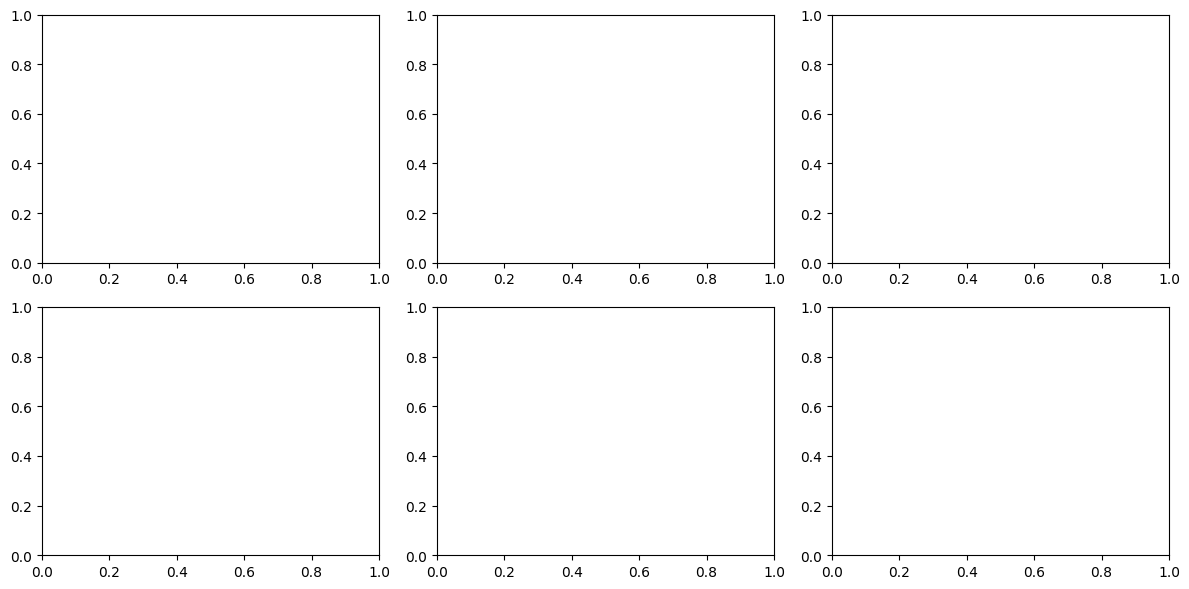

In [65]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Correct Dataset Path
base_path = '/kaggle/input/waste-classification-data/DATASET/TRAIN'

categories = ['Organic', 'Recycle']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,6))

for row, category in enumerate(categories):

    category_path = os.path.join(base_path, category)

    # Safety check (VERY IMPORTANT)
    if not os.path.exists(category_path):
        print("Path not found:", category_path)
        continue

    image_files = os.listdir(category_path)

    selected_images = random.sample(image_files, 3)

    for col, img_file in enumerate(selected_images):

        img_path = os.path.join(category_path, img_file)

        img = Image.open(img_path)

        ax = axes[row][col]
        ax.imshow(img)
        ax.set_title(category)
        ax.axis('off')
plt.tight_layout()
plt.show()

In [15]:
import os
import matplotlib.pyplot as plt

train_dir = r"C:\Final_Project\DATASET\TRAIN"

labels = ['Organic', 'Recyclable']
counts = []

for label in labels:
    path = os.path.join(train_dir, label)

    if os.path.isdir(path):
        files = os.listdir(path)
        counts.append(len(files))
        print(label, "->", len(files))
    else:
        counts.append(0)
        print("Missing:", path)

# 🚨 FINAL SAFETY CHECK
if sum(counts) == 0:
    print("ERROR: No images found. Check dataset path!")
else:
    plt.figure(figsize=(6,6))
    plt.pie(counts, labels=labels, autopct='%1.1f%%')
    plt.title("TRAIN Data Class Distribution")
    plt.axis('equal')
    plt.show()

Missing: C:\Final_Project\DATASET\TRAIN\Organic
Missing: C:\Final_Project\DATASET\TRAIN\Recyclable
ERROR: No images found. Check dataset path!


In [16]:
train_datagen = ImageDataGenerator(rescale = 1.0 / 255.0,
                                   zoom_range = 0.4,
                                   rotation_range = 10,
                                   horizontal_flip = True,
                                   vertical_flip = True,
                                   validation_split = 0.2)

valid_datagen = ImageDataGenerator(rescale = 1.0 / 255.0,
                                   validation_split = 0.2)

test_datagen  = ImageDataGenerator(rescale = 1.0 / 255.0)

In [ ]:
base_model = VGG16(input_shape=(224,224,3), 
                   include_top=False,
                   weights="imagenet")



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [18]:
for layer in base_model.layers:
    layer.trainable=False

In [19]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
model=Sequential()
model.add(base_model)
model.add(Dropout(0.2))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(512,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))
model.add(Dense(512,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
adam = tensorflow.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy',
              metrics=['accuracy'],
              optimizer=adam)

In [21]:
filepath = './best_model.keras'

earlystopping = EarlyStopping(monitor='val_accuracy', 
                              mode='max', 
                              patience=2,
                              verbose=1)

checkpoint = ModelCheckpoint(filepath, 
                             monitor='val_accuracy', 
                             mode='max', 
                             save_best_only=True, 
                             verbose=1)

callback_list = [earlystopping, checkpoint]

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "DATASET/TRAIN",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    "DATASET/TEST",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

Found 5596 images belonging to 2 classes.
Found 2517 images belonging to 2 classes.


In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
model_history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5,
    verbose=1
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.9173 - loss: 0.2004 - val_accuracy: 0.9480 - val_loss: 0.1512
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.9755 - loss: 0.0667 - val_accuracy: 0.9646 - val_loss: 0.1169
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.9907 - loss: 0.0299 - val_accuracy: 0.9631 - val_loss: 0.1359
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 420s 2s/step - accuracy: 0.9895 - loss: 0.0280 - val_accuracy: 0.9603 - val_loss: 0.1639
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 556s 3s/step - accuracy: 0.9925 - loss: 0.0210 - val_accuracy: 0.9631 - val_loss: 0.1693


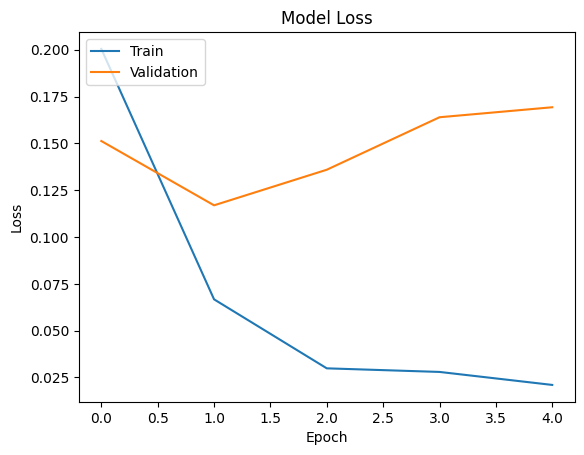

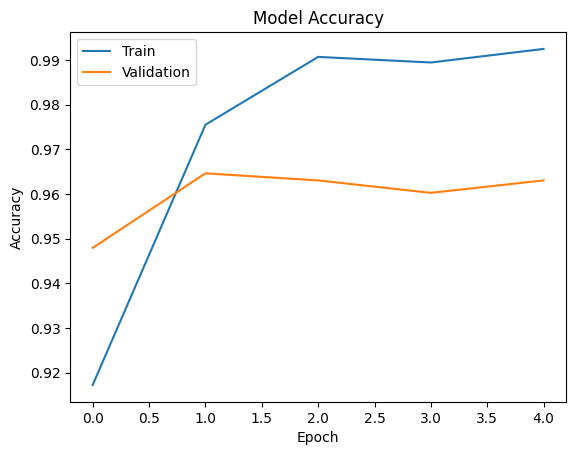

In [28]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Summarize model accuracy

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
import os

print(os.path.exists(r"DATASET"))
print(os.path.exists(r"DATASET"))

import os

target = "Organic"

for root, dirs, files in os.walk("C:\\"):
    if target in dirs:
        print("FOUND DATASET LOCATION:")
        print(root)
        break


In [41]:
import os

for root, dirs, files in os.walk("C:\\"):
    if "Organic" in dirs and "Recyclable" in dirs:
        print("FOUND DATASET HERE:")
        print(root)
        break

In [43]:
import os

for root, dirs, files in os.walk(r"C:\Users\hp\Downloads"):
    if "Organic" in dirs and "Recyclable" in dirs:
        print("FOUND DATASET HERE:")
        print(root)
        break

In [44]:
model.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9631 - loss: 0.1693


[0.16926400363445282, 0.9630512595176697]

In [45]:
resnet = ResNet50(input_shape=(224,224,3), weights='imagenet', include_top=False)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


In [46]:
for layer in resnet.layers:
    layer.trainable=False

In [47]:
model2=Sequential()
model2.add(resnet)
model2.add(Dropout(0.2))
model2.add(Flatten())
model2.add(BatchNormalization())
model2.add(Dense(512,kernel_initializer='he_uniform'))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(Dropout(0.2))
model2.add(Dense(512,kernel_initializer='he_uniform'))
model2.add(BatchNormalization())
model2.add(Activation('relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1,activation='sigmoid'))

In [48]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100352)         │       401,408 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,637,121 (288.53 MB)

 Trainable params: 51,846,657 (197.78 MB)

 Non-trainable params: 23,790,464 (90.75 MB)

In [49]:
adam = tensorflow.keras.optimizers.Adam(learning_rate=0.001)

model2.compile(loss='binary_crossentropy',
              metrics=['accuracy'],
              optimizer=adam)

In [50]:
earlystopping = EarlyStopping(monitor='val_accuracy', 
                              mode='max', 
                              patience=2,
                              verbose=1)


callback_list = [earlystopping]

In [56]:
import os

for root, dirs, files in os.walk(r"C:\Users\hp\Downloads\waste-classification-data"):
    print(root)
    print(dirs)
    print("-"*50)



In [59]:
import os

base = r"C:\Users\hp\Downloads\waste-classification-data"

for root, dirs, files in os.walk(base):
    if "Organic" in dirs:
        print("FOUND TRAIN FOLDER HERE:")
        print(root)
        break

In [60]:
model2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 52s 632ms/step - accuracy: 0.5781 - loss: 0.6769


[0.6769473552703857, 0.5780691504478455]

In [63]:
import os

base = r"C:\Users\hp\Downloads\waste-classification-data"

for root, dirs, files in os.walk(base):
    if len(files) > 0:
        print("Sample file path:", os.path.join(root, files[0]))
        break

In [64]:
model.save('model.h5')

In [66]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [67]:
train_path = r"C:\Users\hp\Downloads\waste-classification-data\DATASET\TRAIN"
test_path  = r"C:\Users\hp\Downloads\waste-classification-data\DATASET\TEST"

In [68]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_gen = ImageDataGenerator(rescale=1./255)

In [78]:
import os

base = r"C:\Users\hp\Downloads"

for root, dirs, files in os.walk(base):
    if "Organic" in dirs and "Recyclable" in dirs:
        print("FOUND TRAIN PATH:")
        print(root)
        break

In [79]:
base_model = VGG16(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(256),
    Activation('relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

In [80]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [81]:
checkpoint = ModelCheckpoint(
    "model.keras",   # IMPORTANT
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

In [74]:
model.save("model.keras")

In [84]:
from tensorflow.keras.models import load_model

model = load_model("model.h5")
print("Model loaded successfully")

Model loaded successfully
